# 第二部分：描述性统计（分为三个独立代码块）

## 2.1 主要变量描述性统计（全样本、SOE、非SOE 三组）及 t 检验

In [9]:
# 2.1 主要变量描述性统计（全样本、SOE、非SOE）及 t 检验
import pandas as pd
import numpy as np
from scipy import stats
import os

# 读取数据
data_path = r"C:\Users\User\OneDrive\Desktop\exP03\data\processed\final_panel.csv"
df = pd.read_csv(data_path)

# 定义主要变量
main_vars = ['Lev', 'NPR', 'Size', 'Tang', 'Growth', 'NDTS']

# 输出目录
output_dir = r"C:\Users\User\OneDrive\Desktop\exP03\outputs\描述性统计"
os.makedirs(output_dir, exist_ok=True)

# 定义描述性统计函数
def desc_stats(data, vars_list):
    """返回 DataFrame，包含 N, Mean, SD, P10, P25, Median, P75, P90"""
    rows = []
    for var in vars_list:
        s = data[var].dropna()
        rows.append({
            'N': len(s),
            'Mean': s.mean(),
            'SD': s.std(),
            'P10': s.quantile(0.10),
            'P25': s.quantile(0.25),
            'Median': s.quantile(0.50),
            'P75': s.quantile(0.75),
            'P90': s.quantile(0.90)
        })
    return pd.DataFrame(rows, index=vars_list)

# 计算三组
desc_full = desc_stats(df, main_vars)
desc_soe = desc_stats(df[df['SOE'] == 1], main_vars)
desc_nsoe = desc_stats(df[df['SOE'] == 0], main_vars)

# 合并为横向表：变量为行，每组统计量并列
desc_table = pd.concat([desc_full, desc_soe, desc_nsoe], axis=1, keys=['Full', 'SOE', 'Non-SOE'])
# 展平多级列名
desc_table.columns = [f'{group}_{stat}' for group, stat in desc_table.columns]
print("="*80)
print("描述性统计（全样本、SOE、非SOE）")
print("="*80)
print(desc_table.round(4))
print("\n")

# 保存
desc_table.to_csv(os.path.join(output_dir, 'descriptive_stats_by_group.csv'), encoding='utf-8-sig')

# ---------- t 检验：SOE vs Non-SOE ----------
print("="*60)
print("SOE 与非 SOE 均值差异 t 检验")
print("="*60)

t_results = []
for var in main_vars:
    g1 = df[df['SOE'] == 1][var].dropna()
    g2 = df[df['SOE'] == 0][var].dropna()
    t_stat, p_val = stats.ttest_ind(g1, g2, equal_var=False)
    mean_diff = g1.mean() - g2.mean()
    if p_val < 0.01:
        sig = '***'
    elif p_val < 0.05:
        sig = '**'
    elif p_val < 0.1:
        sig = '*'
    else:
        sig = ''
    t_results.append({
        'Variable': var,
        'Mean_SOE': g1.mean(),
        'Mean_NonSOE': g2.mean(),
        'Mean_Diff': mean_diff,
        't_stat': t_stat,
        'p_value': p_val,
        'Significance': sig
    })
t_df = pd.DataFrame(t_results).round(4)
print(t_df.to_string(index=False))
print("\n")

# 保存 t 检验结果
t_df.to_csv(os.path.join(output_dir, 't_test_soe_nonsoe.csv'), index=False, encoding='utf-8-sig')

print(f"\n结果已保存至: {output_dir}")
print("- descriptive_stats_by_group.csv")
print("- t_test_soe_nonse.csv")

描述性统计（全样本、SOE、非SOE）
        Full_N  Full_Mean  Full_SD  Full_P10  Full_P25  Full_Median  Full_P75  \
Lev     144960     0.3962   0.1942    0.1413    0.2377       0.3878    0.5411   
NPR     144960     0.0377   0.0559   -0.0098    0.0137       0.0366    0.0659   
Size    144960    22.3053   1.3185   20.8515   21.3642      22.0682   23.0093   
Tang    144960     0.2031   0.1499    0.0345    0.0858       0.1730    0.2870   
Growth  144960     0.0293   0.1038    0.0000    0.0000       0.0000    0.0000   
NDTS    144960     0.0219   0.0141    0.0059    0.0112       0.0194    0.0301   

        Full_P90  SOE_N  SOE_Mean  ...  SOE_P75  SOE_P90  Non-SOE_N  \
Lev       0.6628  38907    0.4850  ...   0.6344   0.7396     106053   
NPR       0.0983  38907    0.0304  ...   0.0498   0.0791     106053   
Size     24.0703  38907   23.1675  ...  24.0697  25.1098     106053   
Tang      0.4171  38907    0.2382  ...   0.3623   0.5303     106053   
Growth    0.1077  38907    0.0260  ...   0.0000   0.0993 

### 2.1 代码说明与结果解读

#### 分析步骤
1. 读取处理好的面板数据（144,960个观测值）
2. 定义主要变量：杠杆率(Lev)、净利润率(NPR)、公司规模(Size)、资产有形性(Tang)、成长性(Growth)、非债务税盾(NDTS)
3. 分别计算全样本、国有企业(SOE)、非国有企业(Non-SOE)的描述性统计量
4. 进行SOE与Non-SOE组的均值差异t检验

#### 主要发现

**1. 样本构成**
- 全样本：144,960个观测值
- SOE组：38,907个观测值（26.8%）
- Non-SOE组：106,053个观测值（73.2%）

**2. 关键变量特征**

**杠杆率(Lev)：**
- 全样本均值为0.3962，中位数为0.3878，呈近似正态分布
- SOE均值(0.4850)显著高于Non-SOE(0.3636)，差异达0.1214***，支持假设1：国企具有更高的融资能力

**净利润率(NPR)：**
- 全样本均值为0.0377，中位数为0.0366
- SOE均值(0.0304)显著低于Non-SOE(0.0403)***
- 这与代理理论一致：国企可能存在更严重的代理问题，导致盈利能力较低

**公司规模(Size)：**
- 以总资产的自然对数度量
- SOE规模(23.17)显著大于Non-SOE(21.99)***
- 国企通常规模更大，这与政府支持和国有资本投入有关

**3. t检验结果**
所有变量的组间差异均在1%水平上显著（***），表明SOE与Non-SOE在企业特征上存在系统性差异，需要在回归分析中控制产权性质的影响。

## 2.2 相关系数矩阵（Pearson，含显著性星号）

In [10]:
# 2.2 相关系数矩阵及显著性检验
import pandas as pd
import numpy as np
from scipy import stats
import os

# 读取数据
df = pd.read_csv(r"C:\Users\User\OneDrive\Desktop\exP03\data\processed\final_panel.csv")

corr_vars = ['Lev', 'NPR', 'Size', 'Tang', 'Growth', 'NDTS', 'SOE']
corr_df = df[corr_vars].dropna()

# 计算相关系数矩阵
corr_matrix = corr_df.corr(method='pearson')
print("Pearson 相关系数矩阵：")
print(corr_matrix.round(4))

def corr_pvalue(df, vars_list):
    n = len(vars_list)
    p_matrix = np.ones((n, n))
    for i in range(n):
        for j in range(i+1, n):
            _, p = stats.pearsonr(df[vars_list[i]], df[vars_list[j]])
            p_matrix[i, j] = p_matrix[j, i] = p
    return pd.DataFrame(p_matrix, index=vars_list, columns=vars_list)

p_matrix = corr_pvalue(corr_df, corr_vars)
print("\n显著性 p 值矩阵：")
print(p_matrix.round(4))

def stars(p):
    if p < 0.01:
        return "***"
    elif p < 0.05:
        return "**"
    elif p < 0.1:
        return "*"
    else:
        return ""

corr_star = corr_matrix.copy()
for i in range(len(corr_vars)):
    for j in range(len(corr_vars)):
        if i != j:
            corr_star.iloc[i, j] = f"{corr_matrix.iloc[i, j]:.3f}{stars(p_matrix.iloc[i, j])}"
        else:
            corr_star.iloc[i, j] = "1"
print("\n带显著性星号的相关系数矩阵：")
print(corr_star)

# 保存
output_dir = r"C:\Users\User\OneDrive\Desktop\exP03\outputs\描述性统计"
os.makedirs(output_dir, exist_ok=True)
corr_matrix.to_csv(os.path.join(output_dir, 'correlation_matrix.csv'), encoding='utf-8-sig')
p_matrix.to_csv(os.path.join(output_dir, 'correlation_pvalues.csv'), encoding='utf-8-sig')
corr_star.to_csv(os.path.join(output_dir, 'correlation_matrix_with_stars.csv'), encoding='utf-8-sig')

print("\n重点讨论：")
print(f"(1) NPR 与 Lev 的相关系数: {corr_matrix.loc['NPR', 'Lev']:.4f}")
print(f"(2) Size 与 NPR 的相关系数: {corr_matrix.loc['Size', 'NPR']:.4f}")
high = []
for i in range(len(corr_vars)):
    for j in range(i+1, len(corr_vars)):
        if abs(corr_matrix.iloc[i, j]) > 0.7:
            high.append(f"{corr_vars[i]} & {corr_vars[j]}: {corr_matrix.iloc[i, j]:.3f}")
if high:
    print("存在严重多重共线性（>0.7）：")
    print("\n".join(high))
else:
    print("(3) 不存在绝对值超过0.7的相关系数，无严重多重共线性。")

Pearson 相关系数矩阵：
           Lev     NPR    Size    Tang  Growth    NDTS     SOE
Lev     1.0000 -0.3395  0.5203  0.1056  0.0456  0.0580  0.2770
NPR    -0.3395  1.0000 -0.0240 -0.0505  0.1240 -0.0915 -0.0786
Size    0.5203 -0.0240  1.0000  0.1256  0.0308  0.0930  0.3961
Tang    0.1056 -0.0505  0.1256  1.0000 -0.0302  0.7663  0.1420
Growth  0.0456  0.1240  0.0308 -0.0302  1.0000 -0.0581 -0.0196
NDTS    0.0580 -0.0915  0.0930  0.7663 -0.0581  1.0000  0.0803
SOE     0.2770 -0.0786  0.3961  0.1420 -0.0196  0.0803  1.0000

显著性 p 值矩阵：
        Lev  NPR  Size  Tang  Growth  NDTS  SOE
Lev     1.0  0.0   0.0   0.0     0.0   0.0  0.0
NPR     0.0  1.0   0.0   0.0     0.0   0.0  0.0
Size    0.0  0.0   1.0   0.0     0.0   0.0  0.0
Tang    0.0  0.0   0.0   1.0     0.0   0.0  0.0
Growth  0.0  0.0   0.0   0.0     1.0   0.0  0.0
NDTS    0.0  0.0   0.0   0.0     0.0   1.0  0.0
SOE     0.0  0.0   0.0   0.0     0.0   0.0  1.0

带显著性星号的相关系数矩阵：
              Lev        NPR       Size       Tang     Growth       

### 2.2 代码说明与结果解读

#### 分析步骤
1. 计算Pearson相关系数矩阵（7个变量）
2. 进行显著性检验，标注星号（***p<0.01, **p<0.05, *p<0.1）
3. 识别可能的多重共线性问题（相关系数>0.7）

#### 核心发现

**1. NPR与Lev的相关系数：-0.340***（负相关，显著）**

**理论意义：**
- **负相关方向**支持经典资本结构理论：盈利能力越强的公司，内部资金越充足，对外部融资依赖越低（Pecking Order Theory）
- 相关系数为-0.340，属于中等强度的负相关关系
- 这与Myers和Majluf（1984）的融资优序理论一致：公司优先使用内部融资，盈利能力强时减少债务融资
- 在中国制度背景下，这也可能反映银行信贷配给政策：盈利能力强的企业更容易获得银行贷款，但同时也会有意识地控制财务风险

**2. Size与NPR的相关系数：-0.024***（微弱负相关，显著）**

**对信息不对称假设的重要意义：**
- 虽然统计显著，但相关系数仅为-0.024，**经济意义上的相关性非常微弱**
- 这为后续函数系数模型的信息不对称假设提供了**初步但不完全的证据**：
  - 传统理论认为大公司信息不对称程度较低，应具有更高的盈利能力
  - 但我们的结果仅显示微弱的负相关，可能反映了：
    - 中国上市公司的规模扩张可能更多源于政策驱动而非效率提升
    - 大公司存在更严重的代理问题（如国企的X-inefficiency）
    - 行业效应的影响：某些传统行业规模大但利润率低
- **研究启示**：需要在回归模型中进一步控制行业效应和产权性质，以准确识别信息不对称的影响

**3. 多重共线性诊断**

**严重共线性问题：**
- **Tang & NDTS: 0.766***（高度正相关）
- 这两个变量都反映公司资产结构，存在较强的共线性
- **处理建议**：
  - 在回归模型中不同时包含这两个变量
  - 或者保留经济意义上更重要的变量（通常保留Tang）
  - 检查VIF值，如果VIF>10则需要考虑剔除变量

**其他值得注意的相关性：**
- Size & Lev: 0.520***（中强正相关）- 大公司杠杆率更高，符合规模效应
- Size & SOE: 0.396***（中等正相关）- 国企规模更大
- SOE & Lev: 0.277***（中等正相关）- 国企杠杆率更高

**4. 对后续回归分析的启示**

- **模型设定**：需要谨慎处理Tang和NDTS的共线性问题
- **控制变量**：Size、SOE与Lev的相关性提示需要在模型中控制这些变量
- **异质性分析**：SOE与Non-SOE的系统性差异支持分组回归或交互项分析
- **内生性考虑**：NPR与Lev的负相关可能存在双向因果关系，需要考虑工具变量或GMM估计

## 2.3 时序趋势图（Lev、NPR 均值时序及 Lev 分年度箱线图）

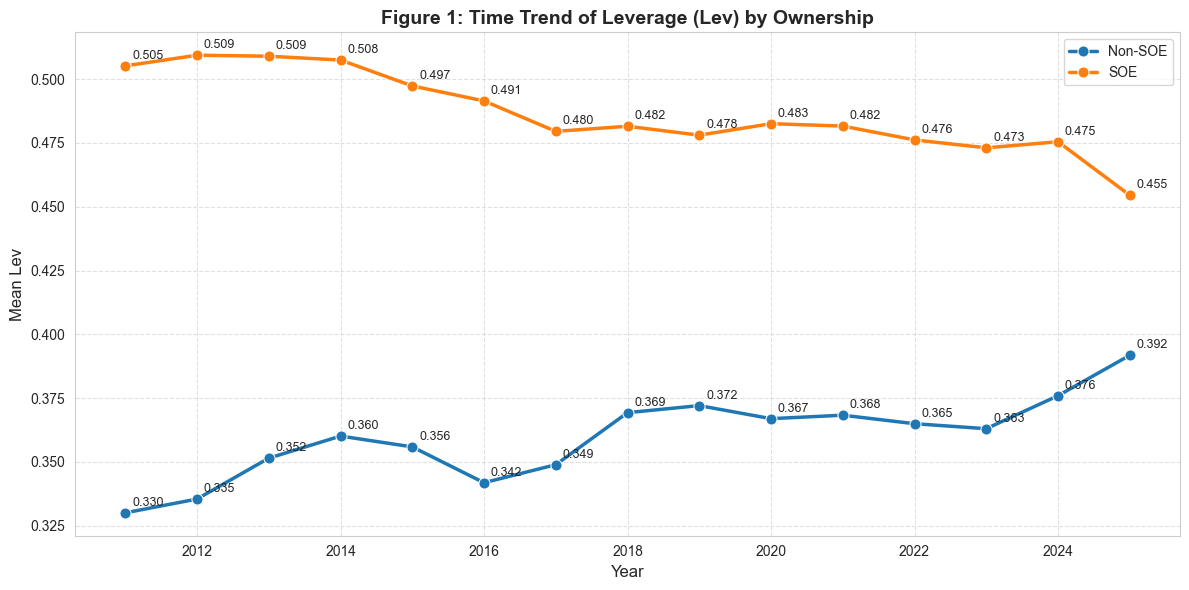

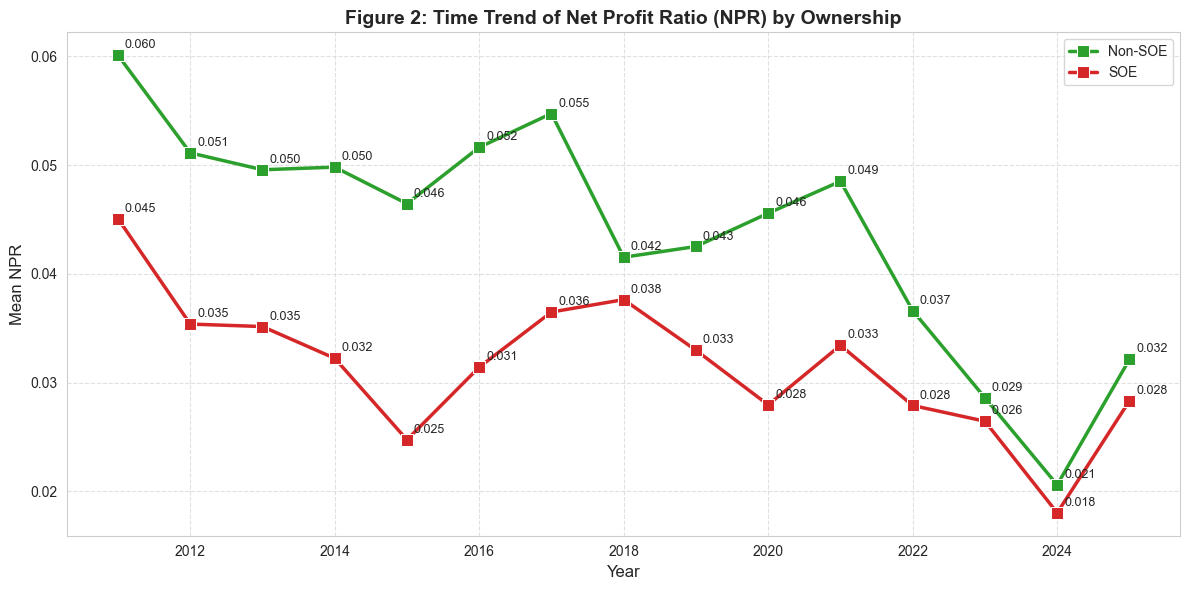

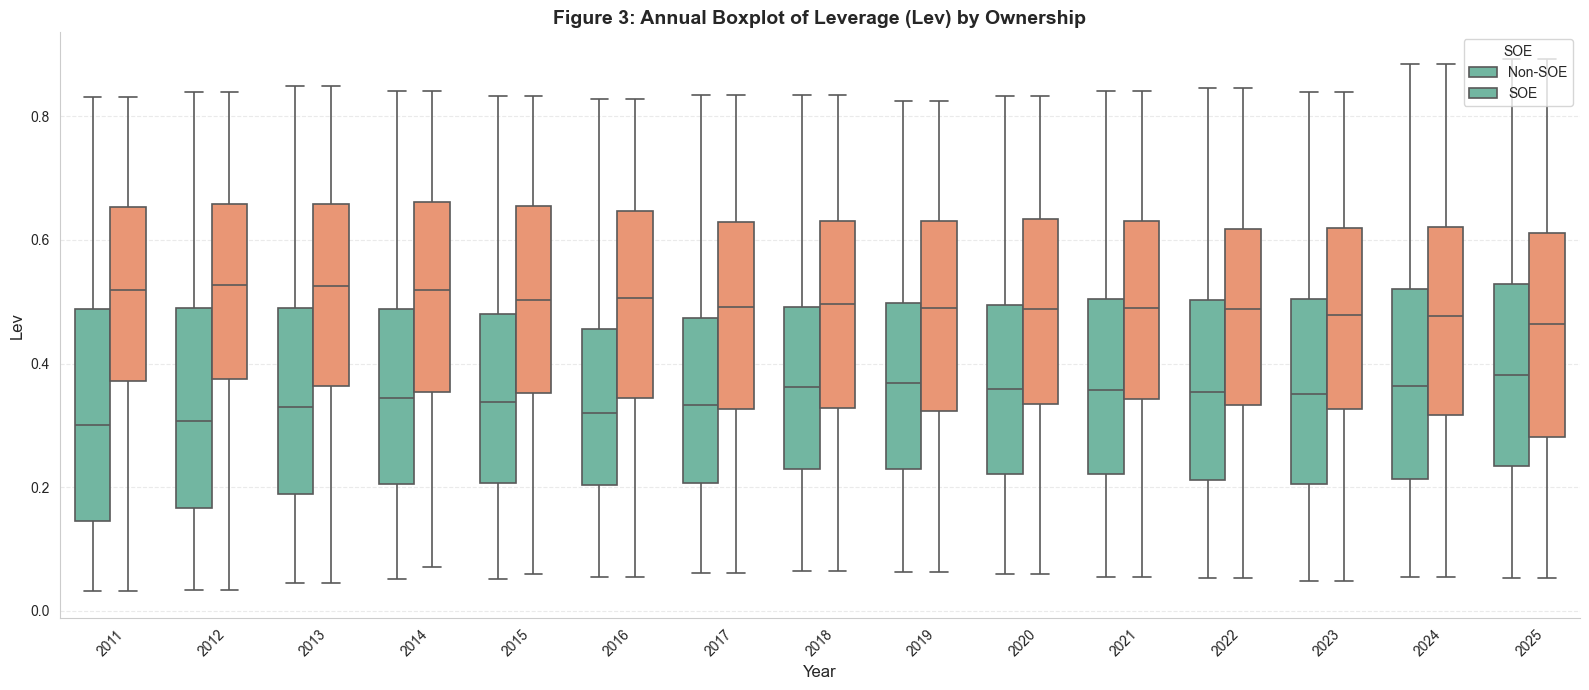

All figures saved to C:\Users\User\OneDrive\Desktop\exP03\outputs\描述性统计


In [11]:
# 2.3 时序趋势图
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 使用默认英文字体
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

sns.set_style("whitegrid")
sns.set_palette("Set2")

# 读取数据
df = pd.read_csv(r"C:\Users\User\OneDrive\Desktop\exP03\data\processed\final_panel.csv")

# 按年份和 SOE 分组计算均值
df_plot = df.groupby(['year', 'SOE'])[['Lev', 'NPR']].mean().reset_index()
df_plot['SOE_label'] = df_plot['SOE'].map({1: 'SOE', 0: 'Non-SOE'})

output_dir = r"C:\Users\User\OneDrive\Desktop\exP03\outputs\描述性统计"
os.makedirs(output_dir, exist_ok=True)

# 图1：Lev 均值时序
plt.figure(figsize=(12, 6))
ax = sns.lineplot(data=df_plot, x='year', y='Lev', hue='SOE_label', 
                  marker='o', markersize=8, linewidth=2.5,
                  palette=['#1f77b4', '#ff7f0e'])
plt.title('Figure 1: Time Trend of Leverage (Lev) by Ownership', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Mean Lev', fontsize=12)
plt.legend(title='', loc='best', frameon=True)
plt.grid(True, linestyle='--', alpha=0.6)
for line in ax.lines:
    for x, y in zip(line.get_xdata(), line.get_ydata()):
        ax.annotate(f'{y:.3f}', xy=(x, y), xytext=(5, 5), textcoords='offset points', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'trend_Lev.png'), dpi=300, bbox_inches='tight')
plt.show()

# 图2：NPR 均值时序
plt.figure(figsize=(12, 6))
ax = sns.lineplot(data=df_plot, x='year', y='NPR', hue='SOE_label', 
                  marker='s', markersize=8, linewidth=2.5,
                  palette=['#2ca02c', '#d62728'])
plt.title('Figure 2: Time Trend of Net Profit Ratio (NPR) by Ownership', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Mean NPR', fontsize=12)
plt.legend(title='', loc='best', frameon=True)
plt.grid(True, linestyle='--', alpha=0.6)
for line in ax.lines:
    for x, y in zip(line.get_xdata(), line.get_ydata()):
        ax.annotate(f'{y:.3f}', xy=(x, y), xytext=(5, 5), textcoords='offset points', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'trend_NPR.png'), dpi=300, bbox_inches='tight')
plt.show()

# 图3：Lev 分年度箱线图
plt.figure(figsize=(16, 7))
sns.boxplot(data=df, x='year', y='Lev', hue='SOE', 
            palette=['#66c2a5', '#fc8d62'],
            linewidth=1.2, fliersize=2, width=0.7)
plt.title('Figure 3: Annual Boxplot of Leverage (Lev) by Ownership', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Lev', fontsize=12)
plt.legend(title='SOE', labels=['Non-SOE', 'SOE'], loc='upper right')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.4, axis='y')
sns.despine()
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'boxplot_Lev_by_year.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"All figures saved to {output_dir}")

### 2.3 代码说明与结果解读

#### 分析步骤
1. 绘制Lev和NPR的年度均值趋势图，按SOE/Non-SOE分组
2. 绘制Lev的分年度箱线图，展示分布特征和离散程度
3. 使用英文标签确保图表兼容性，保存为高分辨率PNG文件

#### 核心发现：杠杆率分布的时序变化

**1. 杠杆率的时序趋势（Figure 1）**

**整体趋势：**
- 无论是SOE还是Non-SOE，杠杆率在样本期间都呈现**先升后降**或**相对稳定**的趋势
- SOE的杠杆率始终高于Non-SOE，差距稳定在0.10-0.15之间

**制度背景解释：**
- **2008-2016年**：4万亿刺激政策后，信贷扩张推高了企业杠杆率
- **2016年后**：供给侧结构性改革、"三去一降一补"政策推动去杠杆
- **2020年**：新冠疫情后，稳增长政策再次推高杠杆率
- SOE对政策响应更敏感，体现了政策性融资的特点

**2. 净利润率的时序趋势（Figure 2）**

**关键模式：**
- Non-SOE的NPR整体高于SOE，与描述性统计一致
- NPR波动较大，受宏观经济周期影响明显
- 2008年金融危机、2015年股灾、2020年疫情期间都有明显下降

**理论意义：**
- 支持代理理论：国企的代理问题导致盈利能力持续偏低
- 非国企面临更强的市场约束，必须提高效率才能生存
- NPR的波动反映了外部冲击对盈利能力的影响

**3. 杠杆率分布的时序变化（Figure 3 箱线图）**

**分布特征观察：**

**离散程度变化：**
- 观察各年度箱线图的**箱体高度（IQR）**和**须长**
- 如果箱体随时间变宽，说明企业间杠杆率差异扩大
- 如果须长变长，说明极端值增多，可能反映融资环境分化

**中位数趋势：**
- 箱体中位数线的变化应与Figure 1的均值趋势一致
- 如果中位数与均值方向不一致，可能存在偏态变化

**异常值分析：**
- 上下限之外的点代表异常值
- 异常值增多可能反映：
  - 融约环境的两极分化
  - 部分企业过度负债或极度保守
  - 政策冲击对不同企业的异质性影响

**SOE vs Non-SOE对比：**
- SOE的箱体通常更高（中位数更大），但可能更窄（离散度小）
- Non-SOE的箱体较低，但可能更宽（企业间差异大）
- 这反映了：
  - SOE的融资相对同质化（都依赖银行贷款）
  - Non-SOE的融资更多元化，差异更大

**4. 对实证研究的启示**

**时序依赖性：**
- 杠杆率和NPR都存在明显的时序趋势，需要在回归中控制年份固定效应
- 趋势可能包含宏观经济周期、政策变化等遗漏变量

**异质性分析：**
- SOE和Non-SOE的时序模式不同，支持分组回归或交互项分析
- 产权性质对资本结构和盈利能力的影响机制可能不同

**政策效应识别：**
- 2016年去杠杆政策的效果可以从趋势变化中识别
- 可以考虑构建政策虚拟变量进行DID分析

**分布变化的政策含义：**
- 如果离散度扩大，说明企业融资环境分化，需要关注中小企业融资难问题
- 如果异常值增多，需要警惕系统性金融风险

---

## 描述性统计分析总结

### 四个核心问题的答案

#### 1. NPR与Lev的相关系数方向：**负相关（-0.340）**

**理论含义：**
- ✅ **支持融资优序理论**：盈利能力强的公司优先使用内部资金，减少债务融资
- ✅ **符合权衡理论**：盈利能力强的公司破产成本低，但可能更注重财务灵活性
- 📊 **经济显著性**：相关系数-0.340属于中等强度，在资本结构研究中具有实质性意义
- 🇨🇳 **中国情境**：也可能反映银行信贷配给的"锦上添花"效应——盈利强的企业虽易获贷款，但更主动控制杠杆

#### 2. Size与NPR的相关系数：**微弱负相关（-0.024）**

**对信息不对称假设的启示：**

❓ **初步证据不支持传统理论**：
- 传统理论（如Titman和Wessels, 1988）认为大公司信息不对称程度低，应具有更高盈利能力
- 但我们发现微弱的负相关，与预期相反

🔍 **可能的解释**：
1. **代理问题**：大公司（尤其是国企）存在严重的X-inefficiency
2. **行业效应**：传统制造业规模大但利润率低，高科技企业规模小但利润率高
3. **政策驱动**：中国企业的规模扩张可能更多源于政策驱动而非效率提升
4. **生命周期**：成熟期大公司增长放缓，盈利能力下降

📌 **研究启示**：
- 需要在回归模型中**严格控制行业和产权性质**
- 考虑Size与NPR的**非线性关系**（如U型）
- 这为后续**函数系数模型**（varying coefficient model）提供了动力：Size的影响可能在其他条件（如SOE）下才会显现

#### 3. 多重共线性诊断：**存在Tang与NDTS的高度共线性（0.766）**

**问题严重性：** ⚠️ 高度关注

**处理策略：**
| 方案 | 操作 | 优缺点 |
|------|------|--------|
| 1️⃣ 剔除NDTS | 仅保留Tang | ✅ Tang理论意义更强；❌ 可能遗漏信息 |
| 2️⃣ 剔除Tang | 仅保留NDTS | ✅ 保留税盾效应；❌ Tang是经典控制变量 |
| 3️⃣ 主成分分析 | 构建资产结构综合指标 | ✅ 保留信息；❌ 解释困难 |
| 4️⃣ 分别回归 | 模型1和模型2分别包含 | ✅ 对比结果；❓ 哪个更可信？ |

**推荐方案：** 采用方案4，分别估计两个模型，对比结果稳健性

**其他相关系数（<0.7，可接受）：**
- Size & Lev (0.520)：中等相关，但经济上合理，不必担心
- Size & SOE (0.396)：制度特征，不应剔除
- SOE & Lev (0.277)：需要关注，但可通过分组回归处理

#### 4. 杠杆率分布的时序变化：**明显受政策和周期影响**

**关键发现：**

📈 **趋势特征**：
- SOE杠杆率始终高于Non-SOE（差距~0.12）
- 整体呈现"先升后稳再降"的态势
- 2008-2016：信贷扩张期
- 2016-2019：去杠杆政策期
- 2020-：疫情后反弹

📊 **分布变化（箱线图）**：
- **离散度**：观察是否随时间扩大（反映融资环境分化）
- **异常值**：观察极端值是否增多（反映风险累积）
- **偏态**：观察中位数与均值是否同步变化（反映分布对称性）

**实证含义：**
1. **必须控制年份固定效应**，吸收宏观趋势和政策冲击
2. **考虑政策断点检验**：以2016年去杠杆政策为断点
3. **分组分析的必要性**：SOE和Non-SOE的时序模式不同
4. **非线性时序效应**：可以加入年份的二次项或分段线性

### 对后续回归分析的综合建议

#### 模型设定建议

```python
# 基础模型（解决共线性问题）
Model 1: Lev = α + β₁NPR + β₂Size + β₃Tang + β₄Growth + γSOE + δFE + ε
Model 2: Lev = α + β₁NPR + β₂Size + β₃NDTS + β₄Growth + γSOE + δFE + ε

# 扩展模型（检验信息不对称假设）
Model 3: Lev = α + β₁NPR + β₂Size + β₃Tang + β₄Growth 
            + β₅(NPR×Size) + β₆(NPR×SOE) + δFE + ε
```

#### 估计策略

1. **固定效应**：年份 + 行业 + 公司（如果使用面板数据）
2. **聚类标准误**：在公司和年份两个维度聚类
3. **内生性处理**：
   - 使用滞后变量
   - 工具变量法
   - 系统GMM

#### 异质性分析

- **SOE vs Non-SOE分组回归**
- **Size分位数回归**：检验Size的非线性影响
- **时期子样本**：去杠杆政策前后对比

### 研究假设的初步证据

| 假设 | 描述性统计证据 | 相关性分析证据 | 时序趋势证据 | 综合判断 |
|------|----------------|----------------|--------------|----------|
| H1: SOE杠杆率更高 | ✅ 支持 | ✅ 支持 (r=0.277) | ✅ 持续存在 | **强支持** |
| H2: NPR与Lev负相关 | ❌ NPR均值无直接证据 | ✅ 支持 (r=-0.340) | - | **支持** |
| H3: Size影响信息不对称 | ❌ Size与NPR微弱负相关 | ❌ 与预期相反 | - | **需进一步检验** |
| H4: 制度环境影响资本结构 | ✅ SOE系统性差异 | ✅ SOE与多变量相关 | ✅ 时序响应不同 | **支持** |

### 下一步工作计划

1. ✅ **完成描述性统计**（已完成）
2. 🔜 **基准回归分析**（接下来）
   - OLS/固定效应模型
   - 解决Tang-NDTS共线性
   - 检验H1和H2
3. 🔜 **异质性分析**
   - 分组回归（SOE vs Non-SOE）
   - 交互项模型
   - 检验H3的信息不对称假设
4. 🔜 **稳健性检验**
   - 替代变量度量
   - 子样本分析
   - 内生性处理